# 06 - Baselines (Mean / Linear / Ridge)

**Goal:** Train three simple regression baselines under the fair protocol and record per-fold metrics. These set the floor for 07+.

**Approved protocol:**
- Per fold, training set = `train_range ∩ fair_subset_indices` (~395k rows). Validation = full val slice (no subset).
- Fresh `RobustScaler` fit on each fold's training intersection (strict fairness; does **not** reuse 04 scalers).
- Baselines fit natively on the `(n, 2)` target matrix; metrics computed per target.
- Roster: `mean` (DummyRegressor), `linear` (LinearRegression), `ridge` (Ridge, alpha=1.0).
- Metrics: MAE, RMSE, R² per target per fold; aggregated as mean ± std across 5 folds.
- All 15 fitted (fold, model) artifacts saved to disk for downstream comparison.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH  = Path('../results/tables/validation_splits.parquet')
SUBSET_PATH  = Path('../data/subsets/fair_subset_indices.parquet')
MODEL_DIR    = Path('../results/models/baselines')
TABLES_DIR   = Path('../results/tables')
FIG_DIR      = Path('../results/figures')
MEMO_PATH    = Path('../results/memos/06_baselines.md')

for d in (MODEL_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data, Splits, Fair Subset

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
subset_idx = pd.read_parquet(SUBSET_PATH)['row_idx'].to_numpy()

assert (np.diff(subset_idx) >= 0).all(), 'Subset indices not monotonic'

print(f'Dataset rows : {len(df):,}')
print(f'Subset rows  : {len(subset_idx):,}')
print(f'Folds        : {sorted(int(f) for f in splits_df["fold"].unique())}')

Dataset rows : 4,178,504
Subset rows  : 1,000,000
Folds        : [1, 2, 3, 4, 5]


## 2. Per-Fold Data Preparation

`prepare_fold(k)` returns `(X_train_scaled, y_train, X_val_scaled, y_val, scaler)` where the training set is restricted to `train_range ∩ subset` and a fresh `RobustScaler` is fit on that intersection. The validation slice is the full untouched fold-`k` validation range.

In [3]:
def prepare_fold(fold_id):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]

    train_idx = subset_idx[(subset_idx >= tr['start_idx']) & (subset_idx < tr['end_idx'])]
    val_idx   = np.arange(va['start_idx'], va['end_idx'])

    X_tr = df[SENSORS].iloc[train_idx].to_numpy()
    y_tr = df[TARGETS].iloc[train_idx].to_numpy()
    X_va = df[SENSORS].iloc[val_idx].to_numpy()
    y_va = df[TARGETS].iloc[val_idx].to_numpy()

    scaler = RobustScaler().fit(X_tr)
    return scaler.transform(X_tr), y_tr, scaler.transform(X_va), y_va, scaler

## 3. Baseline Roster

Three models. `DummyRegressor` is wrapped in `MultiOutputRegressor` (it is single-output by design); `LinearRegression` and `Ridge` handle multi-output natively.

In [4]:
def make_models():
    return {
        'mean':   MultiOutputRegressor(DummyRegressor(strategy='mean')),
        'linear': LinearRegression(),
        'ridge':  Ridge(alpha=1.0, random_state=SEED),
    }

print('Baseline roster:')
for name, m in make_models().items():
    print(f'  {name:>7}: {m.__class__.__name__}')

Baseline roster:
     mean: MultiOutputRegressor
   linear: LinearRegression
    ridge: Ridge


## 4. Train & Evaluate per (fold, model)

Fit on the subset intersection, predict on the full val slice, record per-target metrics, persist the fitted model + its scaler.

In [5]:
records = []
for fold_id in sorted(int(f) for f in splits_df['fold'].unique()):
    X_tr, y_tr, X_va, y_va, scaler = prepare_fold(fold_id)
    print(f'Fold {fold_id}: train={X_tr.shape}, val={X_va.shape}')

    for name, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)

        for t_idx, target in enumerate(TARGETS):
            records.append({
                'fold':   fold_id,
                'model':  name,
                'target': target,
                'mae':    float(mean_absolute_error(y_va[:, t_idx], y_pred[:, t_idx])),
                'rmse':   float(np.sqrt(mean_squared_error(y_va[:, t_idx], y_pred[:, t_idx]))),
                'r2':     float(r2_score(y_va[:, t_idx], y_pred[:, t_idx])),
            })

        out_path = MODEL_DIR / f'fold_{fold_id}_{name}.joblib'
        joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id, 'name': name}, out_path)

metrics_long = pd.DataFrame(records)
print()
print(f'Total records: {len(metrics_long)}  (expect 5 folds × 3 models × 2 targets = 30)')
assert len(metrics_long) == 30

Fold 1: train=(398670, 16), val=(407367, 16)
Fold 2: train=(391532, 16), val=(419449, 16)
Fold 3: train=(392782, 16), val=(407362, 16)
Fold 4: train=(392275, 16), val=(431972, 16)
Fold 5: train=(399678, 16), val=(435098, 16)

Total records: 30  (expect 5 folds × 3 models × 2 targets = 30)


## 5. Aggregate & Save Metrics

In [6]:
long_path    = TABLES_DIR / '06_baseline_metrics_long.parquet'
summary_path = TABLES_DIR / '06_baseline_metrics_summary.parquet'

metrics_long.to_parquet(long_path, index=False)

summary = (metrics_long
           .groupby(['model', 'target'])[['mae', 'rmse', 'r2']]
           .agg(['mean', 'std'])
           .round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index()
summary.to_parquet(summary_path, index=False)

print('Per-fold metrics (head):')
print(metrics_long.head(10).to_string(index=False))
print()
print('Summary (mean ± std across folds):')
print(summary.to_string(index=False))
print()
print(f'Saved: {long_path}')
print(f'Saved: {summary_path}')

Per-fold metrics (head):
 fold  model       target       mae      rmse        r2
    1   mean  methane_ppm 66.305292 75.799738 -0.012780
    1   mean ethylene_ppm  4.748903  5.510334 -0.002318
    1 linear  methane_ppm 21.264971 40.839981  0.705998
    1 linear ethylene_ppm  2.114708  3.689150  0.550735
    1  ridge  methane_ppm 21.250805 40.835294  0.706065
    1  ridge ethylene_ppm  2.113406  3.689444  0.550664
    2   mean  methane_ppm 73.127808 86.453734 -0.008129
    2   mean ethylene_ppm  5.350816  6.270199 -0.199131
    2 linear  methane_ppm 26.460754 54.621833  0.597579
    2 linear ethylene_ppm  1.914457  2.980813  0.728997

Summary (mean ± std across folds):
 model       target  mae_mean  mae_std  rmse_mean  rmse_std  r2_mean  r2_std
linear ethylene_ppm    2.1129   0.3405     3.4989    0.5656   0.5789  0.0890
linear  methane_ppm   22.4339   5.1652    42.8904   11.6172   0.6305  0.0451
  mean ethylene_ppm    5.2144   0.5109     5.8209    0.6881  -0.1646  0.1957
  mean  methane

## 6. Figures

Three panels: (a) MAE by model and target with fold-std error bars, (b) methane predicted-vs-actual scatter for fold 1's best baseline, (c) same for ethylene. "Best" is chosen by mean R² across folds and targets (scale-free).

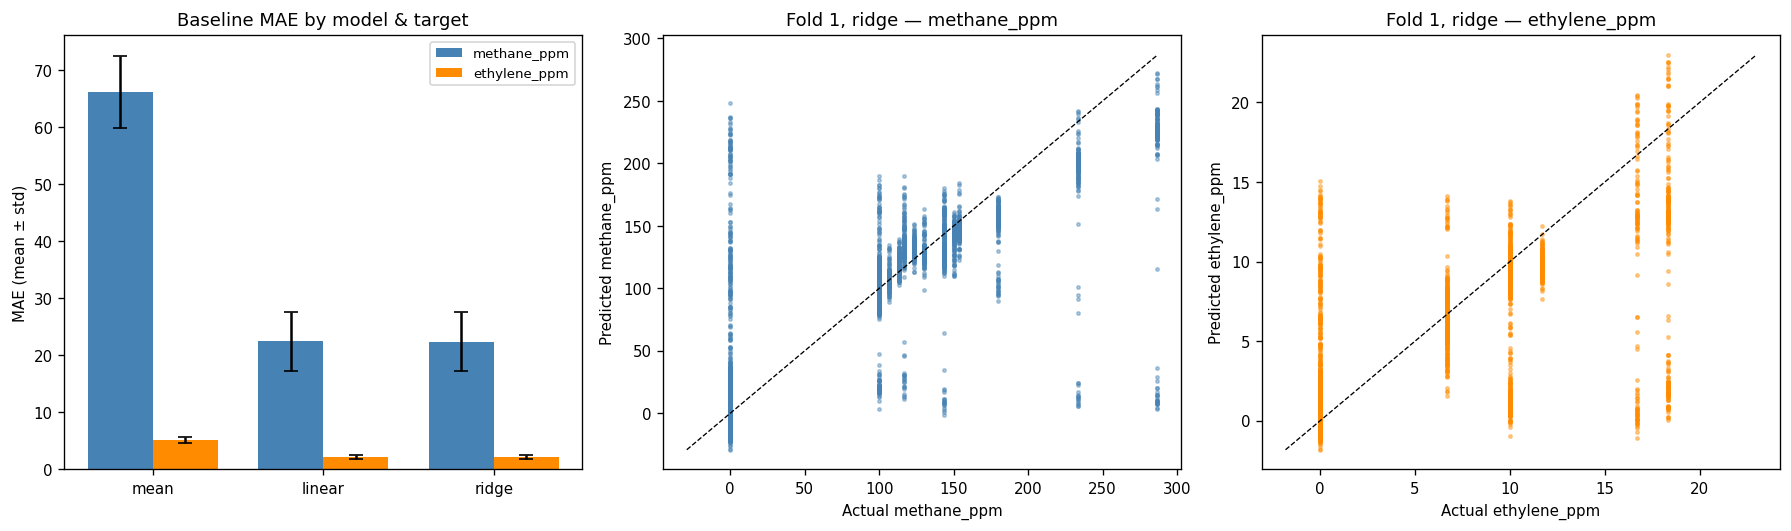

Saved: 06_baselines.png  (best baseline by mean R²: ridge)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
models = list(make_models().keys())
colors = {'methane_ppm': 'steelblue', 'ethylene_ppm': 'darkorange'}

# (a) MAE bars
ax = axes[0]
x = np.arange(len(models))
w = 0.38
for offset, target in zip((-w/2, w/2), TARGETS):
    means = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].mean() for m in models]
    stds  = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].std()  for m in models]
    ax.bar(x + offset, means, w, yerr=stds, capsize=4, label=target, color=colors[target])
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('MAE (mean ± std)'); ax.set_title('Baseline MAE by model & target')
ax.legend(fontsize=8)

# Pick best model by mean R² (pooled across folds & targets, scale-free)
best = metrics_long.groupby('model')['r2'].mean().idxmax()
art  = joblib.load(MODEL_DIR / f'fold_1_{best}.joblib')
va   = splits_df[(splits_df['fold']==1)&(splits_df['split']=='val')].iloc[0]
X_va = df[SENSORS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_va = df[TARGETS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_pred = art['model'].predict(art['scaler'].transform(X_va))

n_plot = min(5000, len(y_va))
samp = np.random.default_rng(SEED).choice(len(y_va), n_plot, replace=False)

for ax, t_idx, target in zip(axes[1:], (0, 1), TARGETS):
    a = y_va[samp, t_idx]; p = y_pred[samp, t_idx]
    ax.scatter(a, p, s=4, alpha=0.4, color=colors[target])
    lo = float(min(a.min(), p.min())); hi = float(max(a.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    ax.set_xlabel(f'Actual {target}'); ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'Fold 1, {best} — {target}')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_baselines.png', bbox_inches='tight')
plt.show()
print(f'Saved: 06_baselines.png  (best baseline by mean R²: {best})')

## 7. Save Memo

In [8]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

ranking = (metrics_long.groupby('model')[['mae', 'rmse', 'r2']]
           .mean().round(4).reset_index()
           .sort_values('r2', ascending=False))
best_model = ranking.iloc[0]['model']

lines = [
    '# 06 - Baselines (Mean / Linear / Ridge)',
    '',
    '**Date:** 2026-05-22',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset artifact:** {SUBSET_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    '- Per fold: training set = `train_range ∩ fair_subset` (~395k rows). Validation = full val slice (untouched).',
    '- Fresh `RobustScaler` fit on each fold\'s training intersection; applied to train and val.',
    '- Baselines fit natively on the (n, 2) target matrix; metrics computed per target.',
    '- 5 folds × 3 models × 2 targets = 30 metric records.',
    '',
    '## Roster',
    '- `mean`   – `DummyRegressor(strategy=mean)` per target (sanity floor).',
    '- `linear` – `LinearRegression()`, native multi-output.',
    '- `ridge`  – `Ridge(alpha=1.0)`, native multi-output.',
    '',
    '## Ranking (mean across folds & targets, sorted by R² descending)',
    '',
    'Note: MAE/RMSE pool across two targets with different scales; R² is the scale-free comparator.',
    '',
    df_to_md(ranking),
    '',
    f'**Best baseline:** `{best_model}`',
    '',
    '## Summary (mean ± std across 5 folds, per target)',
    '',
    df_to_md(summary),
    '',
    '## Artifacts',
    f'- Per-fold metrics: `{long_path.as_posix()}`',
    f'- Summary metrics:  `{summary_path.as_posix()}`',
    f'- Fitted models:    `{MODEL_DIR.as_posix()}/fold_{{k}}_{{name}}.joblib` (15 files)',
    f'- Figure:           `{(FIG_DIR / "06_baselines.png").as_posix()}`',
    '',
    '## Next step',
    'Notebook `07_models.ipynb` (pending approval): non-linear models (tree / boosted) under the same protocol.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\06_baselines.md
